## ReAct Agent Architecture

### Aim

This is the intuition behing ReAct, a general agent architecture.

1. Act - let the model call specific tools
2. Observe - pass the tool output back to the model
3. Reason - let the model reason about the tool output to decide what to do next (e.g., call another tool or just respond directly)

In [3]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

In [4]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max= 500)
arxiv = ArxivQueryRun(api_wrapper = api_wrapper_arxiv)

In [3]:
arxiv.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [5]:
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results = 1, doc_content_chars_max = 500)
wiki = WikipediaQueryRun(api_wrapper= api_wrapper_wiki)

In [5]:
wiki.invoke("What is Machine Learning?")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit instructions. Within a subdiscipline of machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nML fi'

In [7]:
### Tavily Search Tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

In [13]:
tavily.invoke("Provide me the recent AI news for march 7rd 2026")

[{'title': 'AI News Briefs BULLETIN BOARD for March 2026',
  'url': 'https://radicaldatascience.wordpress.com/2026/03/04/ai-news-briefs-bulletin-board-for-march-2026/',
  'content': 'Hybrid language models have been gaining momentum across the field, with recent efforts from projects like Samba, Nemotron-H, Qwen3-Next, Kimi Linear, and Qwen 3.5. By combining transformers’ ability to recall precise details from earlier in a sequence with recurrent layers’ efficiency at tracking evolving state, hybrids promise to be both more capable and cheaper to run at long context lengths. But the community has lacked consensus on whether the purported benefits justify the cost of scaling them up. Olmo Hybrid provides compelling evidence that they do. [...] Pretrained on 6 trillion tokens using an improved data mix, Olmo Hybrid matches Olmo 3 in training throughput—meaning the efficiency gains come from the architecture itself, not from trading speed for performance. After mid-training, Olmo Hybrid o

In [8]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "ReAct_agent"


In [9]:
### Custom functions
def multiply(a: int, b: int) -> int:
    """Multiply a and b.
    
    Args:
        a: first int
        b: second int
    """
    return a * b

def add(a: int, b: int) -> int:
    """Adds a and b.
    
    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> int:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

In [10]:
tools = [arxiv, wiki, tavily, add, multiply, divide]

In [11]:
## Initialize my LLM model
from langchain_groq import ChatGroq

llm_groq = ChatGroq(model="qwen/qwen3-32b", reasoning_format="hidden")

llm_with_tools = llm_groq.bind_tools(tools)

In [12]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

In [17]:
llm_with_tools.invoke([HumanMessage(content = f"What is the recent AI news")])

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '1ssjqtgj9', 'function': {'arguments': '{"query":"recent AI news"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 272, 'prompt_tokens': 637, 'total_tokens': 909, 'completion_time': 0.491046974, 'completion_tokens_details': {'reasoning_tokens': 243}, 'prompt_time': 0.029497762, 'prompt_tokens_details': None, 'queue_time': 0.178923978, 'total_time': 0.520544736}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_99d722e776', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019cc708-c982-7e20-b831-0a02f51b306c-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'recent AI news'}, 'id': '1ssjqtgj9', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 637, 'output_tokens': 272, 'total_tokens': 909, 'output_token_details': {'reasoning': 

In [18]:
llm_with_tools.invoke([HumanMessage(content = f"What is the recent AI news")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'recent AI news'},
  'id': 'bysvjjseq',
  'type': 'tool_call'}]

In [13]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

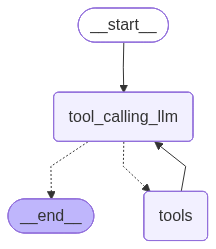

In [14]:
### Entire Chatbot with LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state: State):
    return {"messages" : [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool_call -> tools_conditin routes to END
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [22]:
messages = graph.invoke({"messages": HumanMessage(content="Provide me the top 10 recent AI News for March 7 2026, add 5 plus 5 and then multiply by 10")})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI News for March 7 2026, add 5 plus 5 and then multiply by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (1nyzqmf68)
 Call ID: 1nyzqmf68
  Args:
    query: top 10 recent AI News March 7 2026
  add (r757sx6vc)
 Call ID: r757sx6vc
  Args:
    a: 5
    b: 5
  multiply (ggepext2b)
 Call ID: ggepext2b
  Args:
    a: 10
    b: 10
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "AI News Briefs BULLETIN BOARD for March 2026", "url": "https://radicaldatascience.wordpress.com/2026/03/04/ai-news-briefs-bulletin-board-for-march-2026/", "content": "Hybrid language models have been gaining momentum across the field, with recent efforts from projects like Samba, Nemotron-H, Qwen3-Next, Kimi Linear, and Qwen 3.5. By combining transformer

In [23]:
messages = graph.invoke({"messages": HumanMessage(content="What is Machine Learning?")})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is Machine Learning?
================================== Ai Message ==================================
Tool Calls:
  wikipedia (0r316yyrw)
 Call ID: 0r316yyrw
  Args:
    query: Machine Learning
================================= Tool Message =================================
Name: wikipedia

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit instructions. Within a subdiscipline of machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.
ML fi
================================== Ai Message ==================================

Machine learning (ML) is a branch of *

### Agent Memory

#### Aim

Lets introducce Anget with Memory.

In [15]:
messages = graph.invoke({"messages": HumanMessage(content="What is 5 plus 8?")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 plus 8?
================================== Ai Message ==================================
Tool Calls:
  add (4f9vmq30s)
 Call ID: 4f9vmq30s
  Args:
    a: 5
    b: 8
================================= Tool Message =================================
Name: add

13
================================== Ai Message ==================================

The sum of 5 and 8 is **13**.


In [17]:
messages = [HumanMessage(content="Divide that by five")]
messages = graph.invoke({"messages":messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Divide that by five
================================== Ai Message ==================================

The query is incomplete because it references an unspecified value ("that") to divide by five. Please provide the specific number or context you'd like me to use for the division.


### Memory Saver

LangGraph can use a checkpointer to automatically save the graph state after each step.

This built-in persistence layer gives us memory, allowing LangGraph to pick up from the last state update.

One of the easiest checkpointers to use is the MemorySaver, an in-memory key-value store for Graph state.

All we need to do is simply compile the graph with a checkpointer, and our graph has memory!

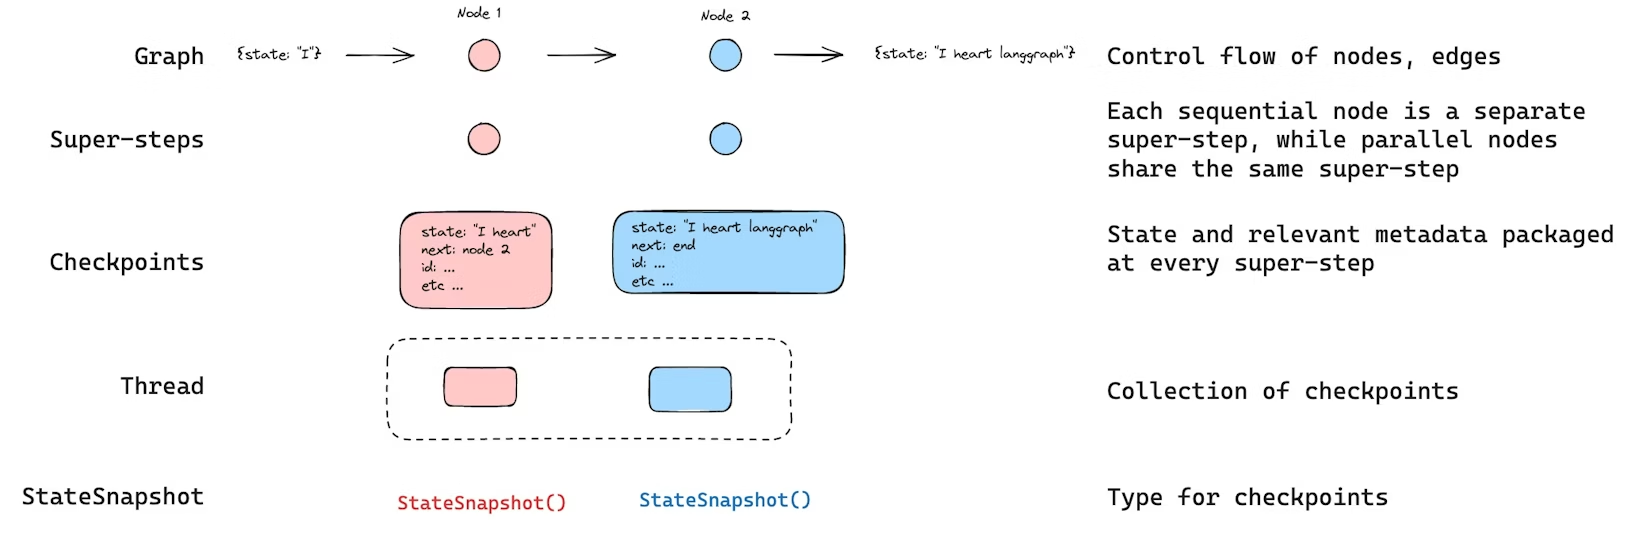

In [31]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model = "gpt-4o")
llm_with_tools = llm.bind_tools(tools)

In [32]:
### Entire Chatbot with LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state: State):
    return {"messages" : [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool_call -> tools_conditin routes to END
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

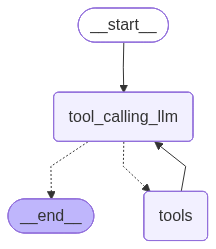

In [33]:
### Initialize MemorySaver and compile the graph

from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

graph_memory = builder.compile(checkpointer = memory)

# View
display(Image(graph_memory.get_graph().draw_mermaid_png()))

In [34]:
## Specify the thread

config = {"configurable" : {"thread_id" : "1"}}

# Specify an input
messages = [HumanMessage(content = "Add 12 and 13.")]

messages = graph_memory.invoke({"messages": messages}, config = config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 12 and 13.
================================== Ai Message ==================================
Tool Calls:
  add (call_ascIZRZwPMxL1LCkCHsVmAXs)
 Call ID: call_ascIZRZwPMxL1LCkCHsVmAXs
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================

The sum of 12 and 13 is 25.


In [35]:
messages = [HumanMessage(content = "Add that number to 25")]

messages = graph_memory.invoke({"messages": messages}, config = config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 12 and 13.
================================== Ai Message ==================================
Tool Calls:
  add (call_ascIZRZwPMxL1LCkCHsVmAXs)
 Call ID: call_ascIZRZwPMxL1LCkCHsVmAXs
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================

The sum of 12 and 13 is 25.
================================ Human Message =================================

Add that number to 25
================================== Ai Message ==================================
Tool Calls:
  add (call_TVm6xGAcOjlAOr6moIrNzCHp)
 Call ID: call_TVm6xGAcOjlAOr6moIrNzCHp
  Args:
    a: 25
    b: 25
================================= Tool Message =================================
Name: add

50
================================== Ai Message ==================================

Adding 25 to the pr

In [36]:
messages = [HumanMessage(content = "Then multiply that number by 2")]

messages = graph_memory.invoke({"messages": messages}, config = config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 12 and 13.
================================== Ai Message ==================================
Tool Calls:
  add (call_ascIZRZwPMxL1LCkCHsVmAXs)
 Call ID: call_ascIZRZwPMxL1LCkCHsVmAXs
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================

The sum of 12 and 13 is 25.
================================ Human Message =================================

Add that number to 25
================================== Ai Message ==================================
Tool Calls:
  add (call_TVm6xGAcOjlAOr6moIrNzCHp)
 Call ID: call_TVm6xGAcOjlAOr6moIrNzCHp
  Args:
    a: 25
    b: 25
================================= Tool Message =================================
Name: add

50
================================== Ai Message ==================================

Adding 25 to the pr